In [434]:
import cartopy.crs as ccrs
import geopandas as gpd
import geoviews as gv
import holoviews as hv
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.ticker import FuncFormatter
from pandas import DataFrame
from sympy.physics.control.control_plots import matplotlib

import thesis_utils as tu

In [435]:
# 1) List font family names Matplotlib can use
families = sorted({ f.name for f in fm.fontManager.ttflist })
print(len(families), "families found")
for n in families[:30]:  # show first 30
  print(n)

# 2) Full table (family, style, weight, file path)
df_fonts = pd.DataFrame([
  { "family": f.name, "style": f.style, "weight": f.weight, "path": f.fname }
  for f in fm.fontManager.ttflist
]).sort_values(["family", "style"]).reset_index(drop=True)
df_fonts.head()

440 families found
.Aqua Kana
.CJK Symbols Fallback HK
.Keyboard
.New York
.SF Arabic
.SF Arabic Rounded
.SF Armenian
.SF Armenian Rounded
.SF Camera
.SF Compact
.SF Compact Rounded
.SF Georgian
.SF Georgian Rounded
.SF Hebrew
.SF Hebrew Rounded
.SF NS Mono
.SF NS Rounded
.SF Soft Numeric
.ThonburiUI
Academy Engraved LET
Adelle Sans Devanagari
AkayaKanadaka
AkayaTelivigala
Al Bayan
Al Nile
Al Tarikh
American Typewriter
Andale Mono
Annai MN
Apple Braille


,family,style,weight,path
0,.Aqua Kana,normal,300,/System/Library/Fonts/AquaKana.ttc
1,.CJK Symbols Fallback HK,normal,250,/System/Library/Fonts/CJKSymbolsFallback.ttc
2,.Keyboard,normal,100,/System/Library/Fonts/Keyboard.ttf
3,.New York,italic,400,/System/Library/Fonts/NewYorkItalic.ttf
4,.New York,normal,400,/System/Library/Fonts/NewYork.ttf


In [436]:
continent_colors = {
  "North America": "#61007D",  # blue
  "Europe": "#1961AE",  # orange
  "Asia": "#F2CD00",  # green
  "South America": "#d62728",  # red
  "Africa": "#9467bd",  # purple
  "Oceania": "#8c564b",  # brown
}

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
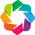

In [437]:
BASE_FONT = "Helvetica"

matplotlib.rcParams.update({
  "font.family": BASE_FONT,
  # optional fine-tuning:
  "font.size": 11,
  "axes.titlesize": 13,
  "axes.labelsize": 12,
  "xtick.labelsize": 10,
  "ytick.labelsize": 10,
  "legend.fontsize": 10,
  "figure.titlesize": 14,
})

hv.extension('bokeh')
gv.extension('bokeh')
# Seaborn setup
custom_rc = {
  "axes.spines.right": False,
  "axes.spines.top": False,
  "axes.edgecolor": "#03071e",
  "grid.linestyle": "dashdot",
  "grid.color": "#4a5759",
  "axes.facecolor": "#edf2fb",
  "patch.edgecolor": "#3c6e71",
}
sns.set_theme(style="whitegrid", rc=custom_rc, font=BASE_FONT)
colors = sns.color_palette("magma")

In [438]:
processed = pd.read_parquet(path="../data/model/processed.parquet", engine="fastparquet")
df: DataFrame = processed.copy(deep=True)
df["dyad_id"] = df["ISO3_reporter"] + "_" + df["ISO3_partner"]
df = df.sort_values(by=["dyad_id", "Year"]).reset_index(drop=True)

In [439]:
iso3_continents = pd.read_csv("../data/geographic/country-continent.csv")

In [440]:
iso3_continents = iso3_continents.rename(columns={ 'Three_Letter_Country_Code': 'ISO3' })

In [441]:
df["ISO3_reporter"] = df["ISO3_reporter"].astype(str).str.strip().str.upper()
iso3_continents["ISO3"] = iso3_continents["ISO3"].astype(str).str.strip().str.upper()

In [442]:
# Merge on ISO3 codes
df_merged = df.merge(
  iso3_continents[["ISO3", "Continent_Name"]],
  left_on="ISO3_reporter",
  right_on="ISO3",
  how="left"
)

In [443]:
# Drop the duplicate "ISO3" column if you don't need it
df_merged = df_merged.drop(columns=["ISO3"])

# Check number of unique reporter codes before/after
print("Unique ISO3_reporter before merge:", df["ISO3_reporter"].nunique())
print("Unique ISO3_reporter after merge:", df_merged["ISO3_reporter"].nunique())

Unique ISO3_reporter before merge: 184
Unique ISO3_reporter after merge: 184


In [444]:
df_merged.describe()

,Year,GDP_reporter,GDP_partner,distcap,distw,IMPORT,EXPORT,arms,military,trade,financial,travel,other,target_mult,sender_mult,GDP_yearly_average
count,1.223382e+06,1.223382e+06,1.223382e+06,1.223382e+06,1.223382e+06,1.223382e+06,1.223382e+06,1.223382e+06,1.223382e+06,1.223382e+06,1.223382e+06,1.223382e+06,1.223382e+06,1.223382e+06,1.223382e+06,1.223382e+06
mean,2.005000e+03,2.865511e+11,2.873709e+11,7.911957e+03,7.927523e+03,2.979791e+05,2.905889e+05,5.834400e-02,3.748134e-02,2.743133e-02,4.160843e-02,3.863716e-02,1.758731e-02,1.594106e-02,7.484416e-02,2.877131e+11
std,1.009962e+01,1.284819e+12,1.305547e+12,4.535132e+03,4.525416e+03,4.072230e+06,4.152343e+06,2.343929e-01,1.899382e-01,1.633367e-01,1.996928e-01,1.927287e-01,1.314459e-01,1.252476e-01,2.631398e-01,1.345961e+11
min,1.988000e+03,7.011059e+06,7.011059e+06,5.961723e+01,9.427333e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.169913e+11
25%,1.996000e+03,3.532969e+09,3.398420e+09,4.330346e+03,4.343689e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.700454e+11
50%,2.005000e+03,1.746539e+10,1.703194e+10,7.469547e+03,7.492123e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.566514e+11
75%,2.014000e+03,1.157393e+11,1.117897e+11,1.118669e+04,1.117023e+04,2.887183e+03,2.535155e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.128200e+11
max,2.022000e+03,2.600689e+13,2.600689e+13,1.990445e+04,1.973532e+04,5.756881e+08,5.827561e+08,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.530808e+11


# GDP

In [445]:
df_merged["GDP_reporter_log"] = np.log1p(df["GDP_reporter"])
df_merged["GDP_reporter_log"].describe()

count    1.178547e+06
mean     2.364472e+01
std      2.507770e+00
min      1.576300e+01
25%      2.194740e+01
50%      2.356054e+01
75%      2.544074e+01
max      3.088938e+01
Name: GDP_reporter_log, dtype: float64

## Violin Plot

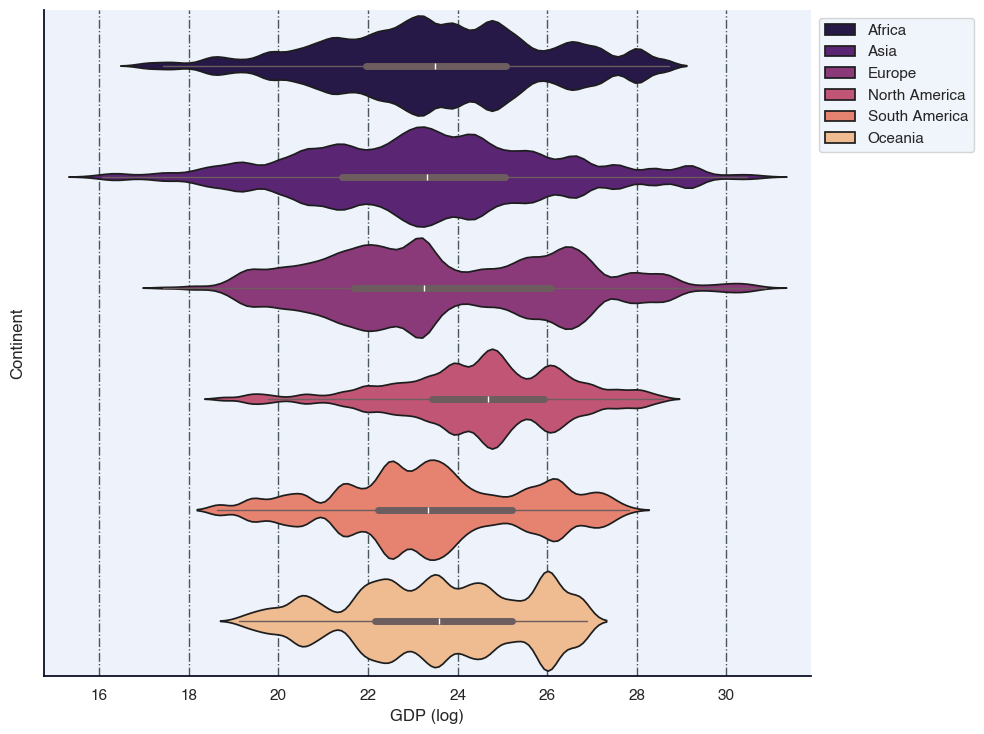

In [446]:
plt.figure(figsize=(10, 7.5))
sns.violinplot(data=df_merged, x="GDP_reporter_log", hue="Continent_Name",
               hue_order=["Africa", "Asia", "Europe", "North America", "South America", "Oceania"],
               palette=colors, width=1, gap=0.1, inner_kws=dict(box_width=5, whis_width=1, color="#6d5d5e"))
plt.ylabel("Continent")
plt.xlabel("GDP (log)")
plt.xlim(
  left=df_merged["GDP_reporter_log"].min() - 1,
  right=df_merged["GDP_reporter_log"].max() + 1
)
plt.legend(
  loc="upper left",
  bbox_to_anchor=(1, 1),
  frameon=True
)
plt.tight_layout()
plt.savefig(
  "graph_output/violin_gdp_by_continent.png",  # use .pdf or .png for thesis
  dpi=500,
  bbox_inches="tight"
)
plt.show()

## GDP Development per Year per Continent

<Figure size 1200x600 with 0 Axes>

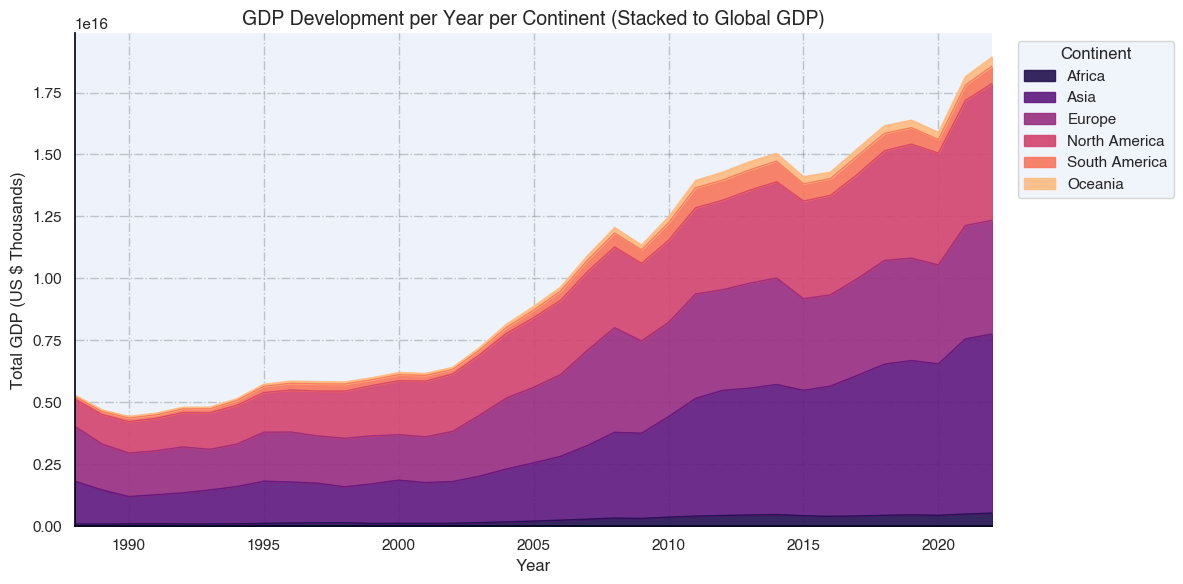

In [447]:
gdp_yearly = (
  df_merged.groupby(["Year", "Continent_Name"])["GDP_reporter"]
  .sum()
  .reset_index()
)

continent_order = ["Africa", "Asia", "Europe", "North America", "South America", "Oceania"]
# Pivot for stacked plotting
gdp_pivot = gdp_yearly.pivot(index="Year", columns="Continent_Name", values="GDP_reporter").fillna(0)

# Reorder columns in the pivot table
gdp_pivot = gdp_pivot[continent_order]

plt.figure(figsize=(12, 6))
gdp_pivot.plot(
  kind="area",
  stacked=True,
  alpha=0.9,
  linewidth=1,
  figsize=(12, 6),
  color=colors
)

plt.title("GDP Development per Year per Continent (Stacked to Global GDP)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Total GDP (US $ Thousands)")
plt.xlim(left=1988, right=2022)
plt.legend(
  title="Continent",
  loc="upper left",
  bbox_to_anchor=(1.02, 1),
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
  "graph_output/gdp_development_stacked.png",  # use .pdf or .png for thesis
  dpi=500,
  bbox_inches="tight"
)
plt.show()

## GDP Development of Selected Countries

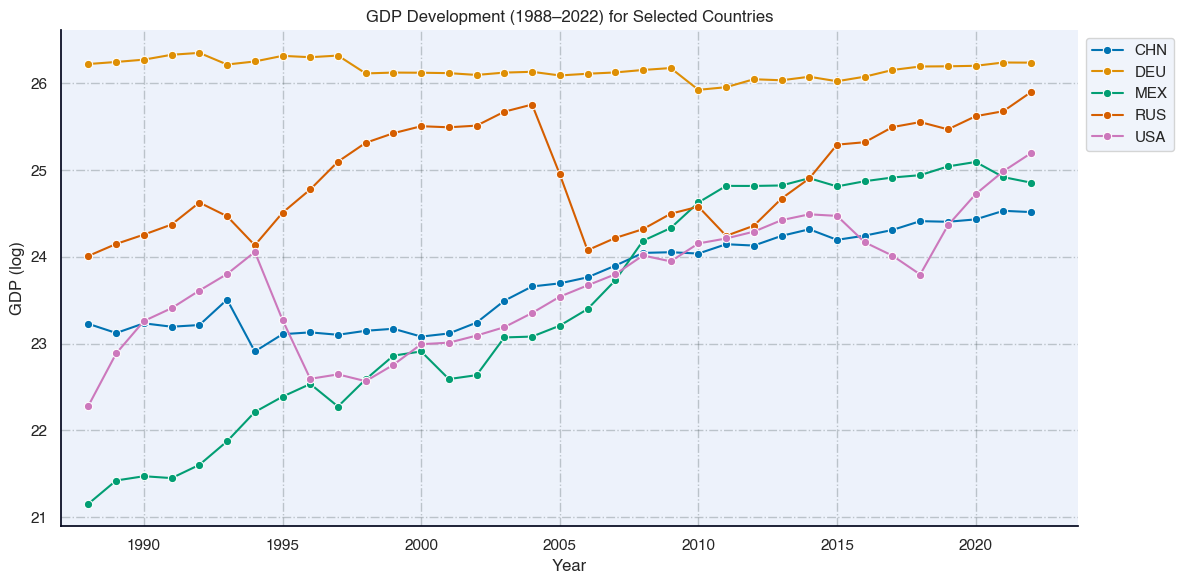

In [448]:
# Subset for selected countries
countries = ["USA", "CHN", "DEU", "MEX", "RUS"]
df_subset = df_merged[df_merged["ISO3_reporter"].isin(countries)]

# Plot GDP development
plt.figure(figsize=(12, 6))
sns.lineplot(
  data=df_subset,
  x="Year",
  y="GDP_reporter_log",
  hue="ISO3_reporter",
  marker="o",
  errorbar=None,
  palette="colorblind",
)

plt.title("GDP Development (1988–2022) for Selected Countries")
plt.xlabel("Year")
plt.ylabel("GDP (log)")
plt.xlim(left=1987)
plt.grid(True, alpha=0.3)
plt.legend(title="Country", loc="upper left")
plt.legend(
  loc="upper left",
  bbox_to_anchor=(1, 1),
  frameon=True
)
plt.tight_layout()
plt.savefig(
  "graph_output/gdp_development_selected.png",  # use .pdf or .png for thesis
  dpi=500,
  bbox_inches="tight"
)
plt.show()

# CEPII

## Intra vs Intre Regional Violin

                    count         mean          std        min       25%  \
Region_type                                                                
Inter-regional  1016559.0  9032.597494  4200.232654  222.07540  5722.741   
Intra-regional   253128.0  3176.888753  2025.026353   94.27333  1556.514   

                     50%        75%        max  
Region_type                                     
Inter-regional  8657.187  12071.880  19735.320  
Intra-regional  2762.906   4452.367   9772.055  


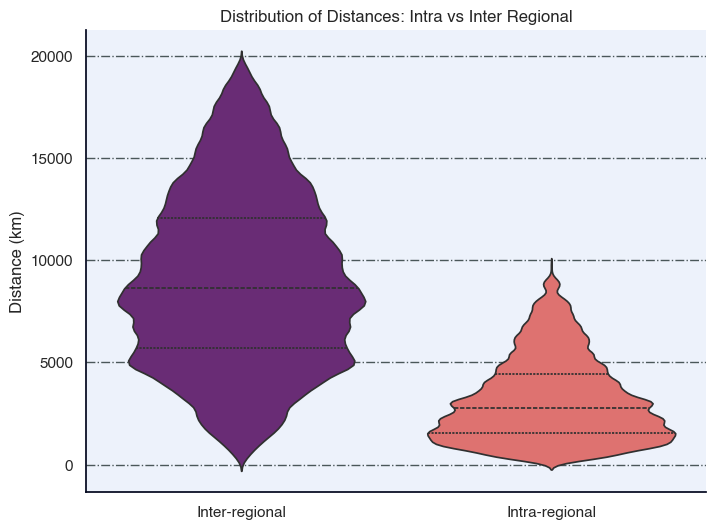

In [449]:
df_dist = df.copy()
df_dist = df_dist.merge(iso3_continents, left_on="ISO3_reporter", right_on="ISO3", how="left").rename(
  columns={ "Continent_Name": "Continent_reporter" })
df_dist = df_dist.merge(iso3_continents, left_on="ISO3_partner", right_on="ISO3", how="left").rename(
  columns={ "Continent_Name": "Continent_partner" })

# Define intra vs inter regional
df_dist["Region_type"] = np.where(
  df_dist["Continent_reporter"] == df_dist["Continent_partner"],
  "Intra-regional",
  "Inter-regional"
)

# Compare average distances
print(df_dist.groupby("Region_type")["distw"].describe())

# Plot distributions
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_dist, x="Region_type", y="distw", inner="quartile", hue=df_dist["Region_type"], palette="magma")
plt.title("Distribution of Distances: Intra vs Inter Regional")
plt.ylabel("Distance (km)")
plt.xlabel("")
plt.show()

## Violin Plot distribution

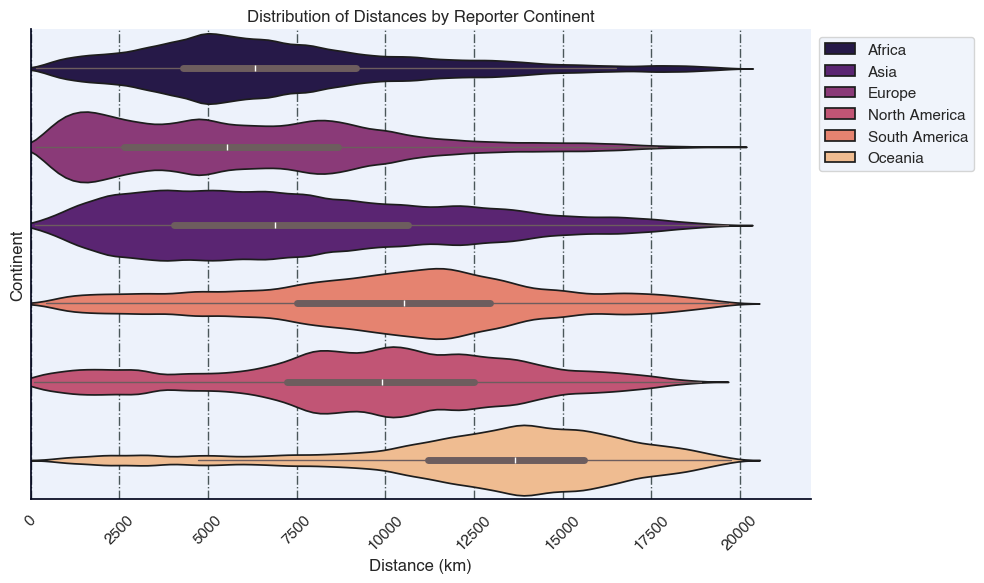

In [450]:
plt.figure(figsize=(10, 6))
sns.violinplot(
  data=df_dist, x="distw", y="Continent_reporter",
  hue=df_dist["Continent_reporter"],
  hue_order=["Africa", "Asia", "Europe", "North America", "South America", "Oceania"],
  palette=colors,
  width=1,
  gap=0.1,
  inner_kws=dict(box_width=5, whis_width=1, color="#6d5d5e")
)
plt.title("Distribution of Distances by Reporter Continent")
plt.xlabel("Distance (km)")
plt.ylabel("Continent")
plt.yticks([])
plt.xticks(rotation=45)
plt.xlim(
  left=0,
  right=22000
)
plt.legend(
  loc="upper left",
  bbox_to_anchor=(1, 1),
  frameon=True
)
plt.tight_layout()
plt.savefig(
  "graph_output/distance_distributions.png",
  dpi=500,
  bbox_inches="tight"
)
plt.show()

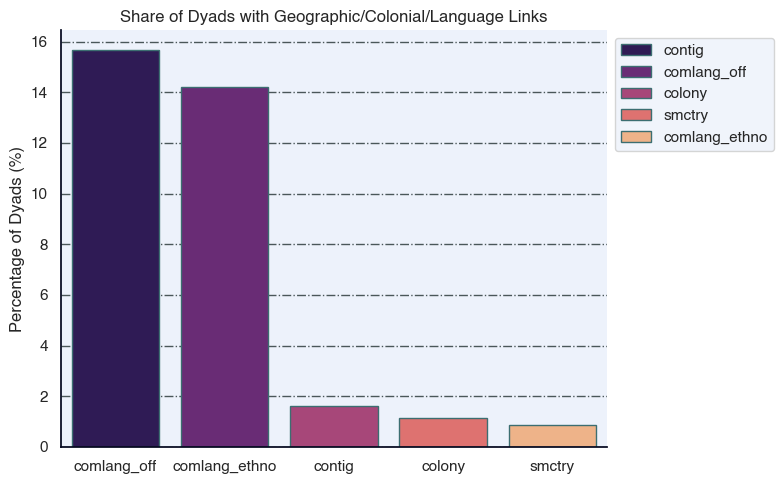

In [451]:
binary_cols = ["contig", "comlang_off", "colony", "smctry", "comlang_ethno"]

share = df[binary_cols].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=share.index, y=share.values, hue=binary_cols, palette="magma")
plt.ylabel("Percentage of Dyads (%)")
plt.xlabel("")
plt.title("Share of Dyads with Geographic/Colonial/Language Links")
plt.legend(
  loc="upper left",
  bbox_to_anchor=(1, 1),
  frameon=True
)
plt.tight_layout()
plt.savefig(
  "graph_output/dyads_share.png",
  dpi=500,
  bbox_inches="tight"
)
plt.show()

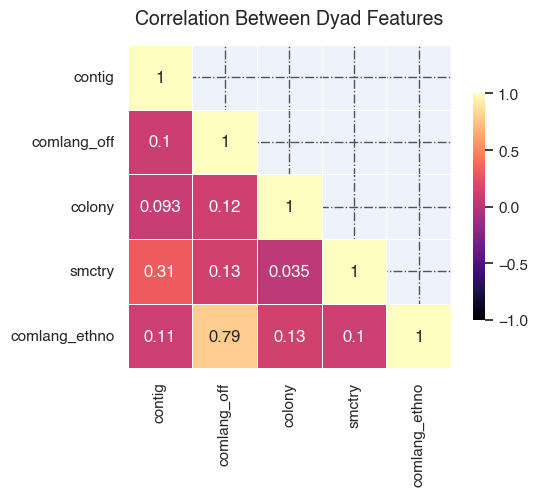

In [452]:
binary_cols = ["contig", "comlang_off", "colony", "smctry", "comlang_ethno"]

corr = df[binary_cols].corr()

# Mask only the upper triangle *above* the diagonal
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(6, 5))
sns.heatmap(
  corr,
  mask=mask,
  annot=True,
  cmap="magma",
  vmin=-1, vmax=1,
  center=0,
  square=True,
  linewidths=0.5,
  cbar_kws={ "shrink": 0.7 }
)
plt.title("Correlation Between Dyad Features", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Sanctions

## Stacked plot

In [453]:
df_sanctions = df_merged.copy(deep=True)
df_sanctions

,ISO3_reporter,UNDS_reporter,CNAME_reporter,ISO3_partner,UNDS_partner,CNAME_partner,Year,GDP_reporter,GDP_partner,contig,...,descr_trade,financial,travel,other,target_mult,sender_mult,GDP_yearly_average,dyad_id,Continent_Name,GDP_reporter_log
0,AGO,024,Angola,ALB,008,Albania,1988,8.769837e+09,2.051236e+09,False,...,,0.0,0.0,0.0,0.0,0.0,1.169913e+11,AGO_ALB,Africa,22.894584
1,AGO,024,Angola,ALB,008,Albania,1989,1.020178e+10,2.253090e+09,False,...,,0.0,0.0,0.0,0.0,0.0,1.220728e+11,AGO_ALB,Africa,23.045828
2,AGO,024,Angola,ALB,008,Albania,1990,1.122952e+10,2.028554e+09,False,...,,0.0,0.0,0.0,0.0,0.0,1.275165e+11,AGO_ALB,Africa,23.141811
3,AGO,024,Angola,ALB,008,Albania,1991,1.060378e+10,1.099559e+09,False,...,,0.0,0.0,0.0,0.0,0.0,1.318462e+11,AGO_ALB,Africa,23.084477
4,AGO,024,Angola,ALB,008,Albania,1992,8.307811e+09,6.521750e+08,False,...,,0.0,0.0,0.0,0.0,0.0,1.406654e+11,AGO_ALB,Africa,22.840462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1223377,ZWE,716,Zimbabwe,ZMB,894,Zambia,2018,3.415607e+10,2.631151e+10,True,...,,0.0,0.0,0.0,0.0,0.0,4.677283e+11,ZWE_ZMB,Africa,NaN
1223378,ZWE,716,Zimbabwe,ZMB,894,Zambia,2019,2.571741e+10,2.330867e+10,True,...,,0.0,0.0,0.0,0.0,0.0,4.770279e+11,ZWE_ZMB,Africa,NaN
1223379,ZWE,716,Zimbabwe,ZMB,894,Zambia,2020,2.686794e+10,1.813776e+10,True,...,,0.0,0.0,0.0,0.0,0.0,4.638722e+11,ZWE_ZMB,Africa,NaN
1223380,ZWE,716,Zimbabwe,ZMB,894,Zambia,2021,2.724052e+10,2.209642e+10,True,...,,0.0,0.0,0.0,0.0,0.0,5.315657e+11,ZWE_ZMB,Africa,NaN


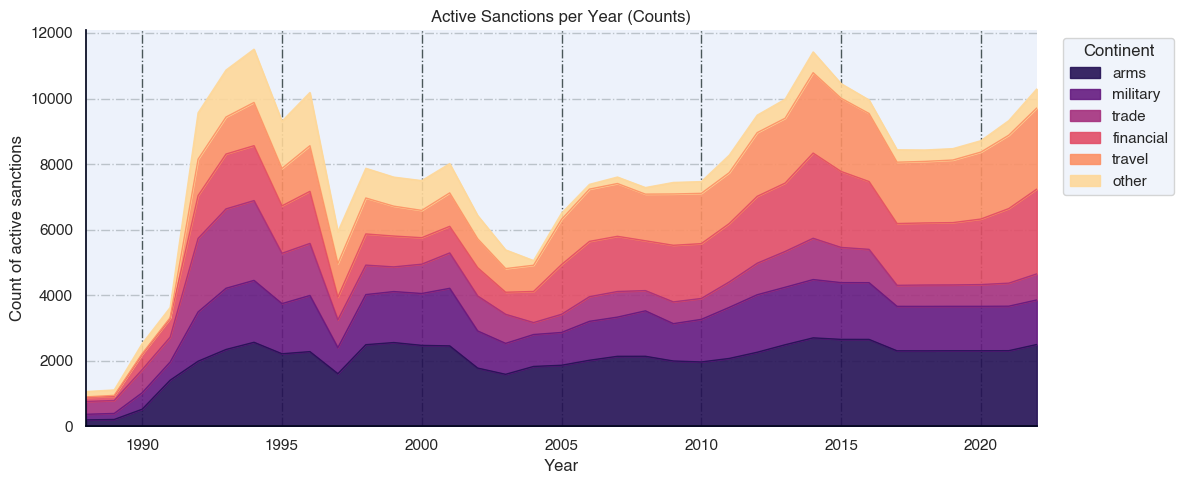

In [454]:
ALL_SANCTION_COLS = ["arms", "military", "trade", "financial", "travel", "other"]


def plot_sanctions_stacked_counts(
    df,
    reporter=None,
    partner=None,
    category_order=("arms", "military", "trade", "financial", "travel", "other"),
    palette="magma",
    alpha=0.9,
):
  # Detect year column
  year_col = "Year" if "Year" in df.columns else ("YEAR" if "YEAR" in df.columns else None)
  if year_col is None:
    raise ValueError("No 'Year' or 'YEAR' column found.")

  # Optional filtering
  dff = df.copy()
  if reporter is not None and "REPORTER" in dff.columns:
    dff = dff[dff["REPORTER"] == reporter]
  if partner is not None and "PARTNER" in dff.columns:
    dff = dff[dff["PARTNER"] == partner]

  # Keep existing sanction columns
  sanc_cols = [c for c in ALL_SANCTION_COLS if c in dff.columns]
  if not sanc_cols:
    raise ValueError("No sanction category columns found.")

  # Ensure numeric 0/1
  dff[sanc_cols] = dff[sanc_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

  # Aggregate per year
  per_year = (
    dff.groupby(year_col, as_index=True)[sanc_cols]
    .sum()
    .sort_index()
    .astype(float)
  )

  # Reorder categories if requested
  if category_order:
    sanc_cols = [c for c in category_order if c in sanc_cols]
    per_year = per_year[sanc_cols]

  # Colors
  cmap = plt.get_cmap(palette)
  colors = cmap(np.linspace(0.15, 0.92, len(sanc_cols)))

  # Plot single stacked area (counts)
  ax = per_year.plot(
    kind="area",
    stacked=True,
    alpha=alpha,
    linewidth=1,
    color=colors,
    figsize=(12, 5),
  )

  ax.set_title("Active Sanctions per Year (Counts)")
  ax.set_xlabel("Year")
  ax.set_ylabel("Count of active sanctions")
  ax.grid(alpha=0.3, axis="y")

  plt.legend(
    title="Continent",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
  )

  plt.xlim(left=1988, right=2022)
  plt.tight_layout()

  plt.savefig(
    "graph_output/active_sanctions.png",
    dpi=500,
    bbox_inches="tight"
  )

  plt.show()


plot_sanctions_stacked_counts(df_sanctions)

## Region Sender-Target heatmap

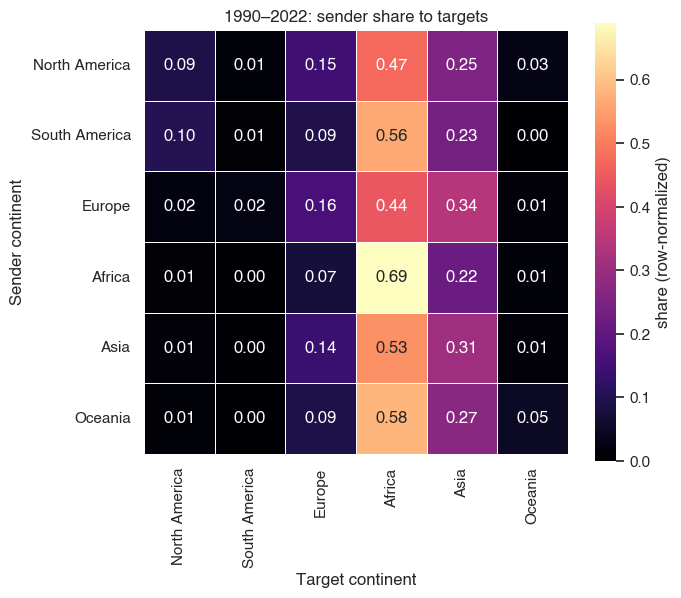

In [455]:
def _unique_iso_to_continent(df, iso_col='ISO3_reporter', continent_col='Continent_Name'):
  """
  Build a unique ISO3 -> continent dict by taking the mode per ISO3.
  Falls back to the first value if there's no unique mode.
  """
  tmp = df[[iso_col, continent_col]].dropna()
  mapper = (tmp.groupby(iso_col)[continent_col]
            .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
            .to_dict())
  return mapper


def sanctions_flow_heatmap(df_sanctions,
                           year_min=1988, year_max=2022,
                           categories=('arms', 'military', 'trade', 'financial', 'travel', 'other'),
                           continent_col='Continent_Name',
                           normalize=None,  # None | 'row' | 'global'
                           cmap='magma', fmt='.0f',
                           title='Sanctions flows by continent'):
  df = df_sanctions.copy()

  # 1) Build a unique ISO3->continent map and apply to both ends
  iso2cont = _unique_iso_to_continent(df, iso_col='ISO3_reporter', continent_col=continent_col)
  # (same dict works for partners since it's the same code space)
  df['source'] = df['ISO3_reporter'].map(iso2cont)
  df['target'] = df['ISO3_partner'].map(iso2cont)

  # 2) Year filter
  df = df[(df['Year'] >= year_min) & (df['Year'] <= year_max)]

  # 3) Active-any flag across categories
  cat_cols = list(categories)
  df['active_any'] = (df[cat_cols].sum(axis=1) > 0).astype(int)

  # 4) Aggregate to sender->target continent
  mat = (df.dropna(subset=['source', 'target'])
         .pivot_table(index='source', columns='target',
                      values='active_any', aggfunc='sum')
         .fillna(0).astype(float))

  # 5) Optional normalization
  if normalize == 'row':
    mat = mat.div(mat.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    fmt = '.2f'
    cbar_label = 'share (row-normalized)'
  elif normalize == 'global':
    total = mat.values.sum()
    mat = mat / total if total else mat
    fmt = '.3f'
    cbar_label = 'share (global)'
  else:
    cbar_label = 'count'

  # Consistent order
  continent_order = ['North America', 'South America', 'Europe', 'Africa', 'Asia', 'Oceania']
  # keep only continents present, preserve order
  present_rows = [c for c in continent_order if c in mat.index]
  present_cols = [c for c in continent_order if c in mat.columns]
  mat = mat.reindex(index=present_rows, columns=present_cols)

  # 6) Plot
  plt.figure(figsize=(7, 6))
  sns.heatmap(mat, cmap=cmap, annot=True, fmt=fmt, linewidths=0.5, square=True,
              cbar_kws={ 'label': cbar_label })
  plt.title(title)
  plt.xlabel('Target continent')
  plt.ylabel('Sender continent')
  plt.tight_layout()
  plt.savefig(
    "graph_output/sender_share_to_target.png",
    dpi=500,
    bbox_inches="tight"
  )
  plt.show()


# Example:
sanctions_flow_heatmap(df_sanctions, normalize='row',
                       title='1990–2022: sender share to targets')

# Trade

## Export over years

In [456]:
df_trade = df_merged.copy(deep=True)

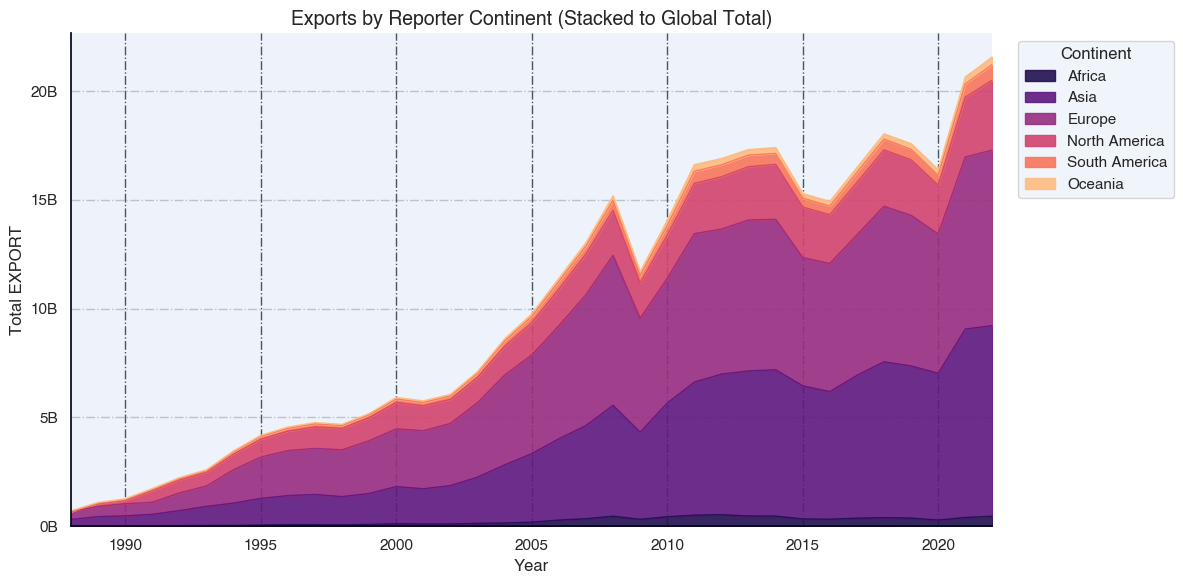

In [457]:
# --- 1) Aggregate: total EXPORT per Year × Continent_Name ---
exports_yearly = (
  df_trade
  .assign(EXPORT=pd.to_numeric(df_merged["EXPORT"], errors="coerce"))
  .dropna(subset=["EXPORT", "Year", "Continent_Name"])
  .groupby(["Year", "Continent_Name"], observed=True)["EXPORT"]
  .sum()
  .reset_index()
)

# --- 2) Pivot to Year × Continent matrix ---
exports_pivot = (
  exports_yearly
  .pivot(index="Year", columns="Continent_Name", values="EXPORT")
  .fillna(0)
)

# Optional: control order + palette
continent_order = ["Africa", "Asia", "Europe", "North America", "South America", "Oceania"]
exports_pivot = exports_pivot.reindex(columns=[c for c in continent_order if c in exports_pivot.columns])

colors = sns.color_palette("magma", n_colors=exports_pivot.shape[1])

# --- 3) Plot stacked area ---
fig, ax = plt.subplots(figsize=(12, 6))
exports_pivot.plot(
  kind="area",
  stacked=True,
  alpha=0.9,
  linewidth=1,
  color=colors,
  ax=ax
)

ax.set_title("Exports by Reporter Continent (Stacked to Global Total)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Total EXPORT")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x / 1e9:.0f}B"))

ax.set_xlim(left=exports_pivot.index.min(), right=exports_pivot.index.max())
ax.grid(alpha=0.3, axis="y")

ax.legend(title="Continent", loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig(
  "graph_output/exports_by_continent.png",
  dpi=500,
  bbox_inches="tight"
)
plt.show()

/var/folders/wz/kf7643gn3_s2867t_nnc9zxc0000gn/T/ipykernel_23375/2637140913.py:41: UserWarning: 
The palette list has fewer values (6) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(
/var/folders/wz/kf7643gn3_s2867t_nnc9zxc0000gn/T/ipykernel_23375/2637140913.py:41: UserWarning: 
The palette list has fewer values (6) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(
/var/folders/wz/kf7643gn3_s2867t_nnc9zxc0000gn/T/ipykernel_23375/2637140913.py:41: UserWarning: 
The palette list has fewer values (6) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(
/var/folders/wz/kf7643gn3_s2867t_nnc9zxc0000gn/T/ipykernel_23375/2637140913.py:41: UserWarning: 
The palette list has fewer values (6) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(
/var/folders/wz/kf7643gn3_s2867t_nnc9zxc0000gn/T/ipykernel_23375/2637140913.py:41: UserWarning: 

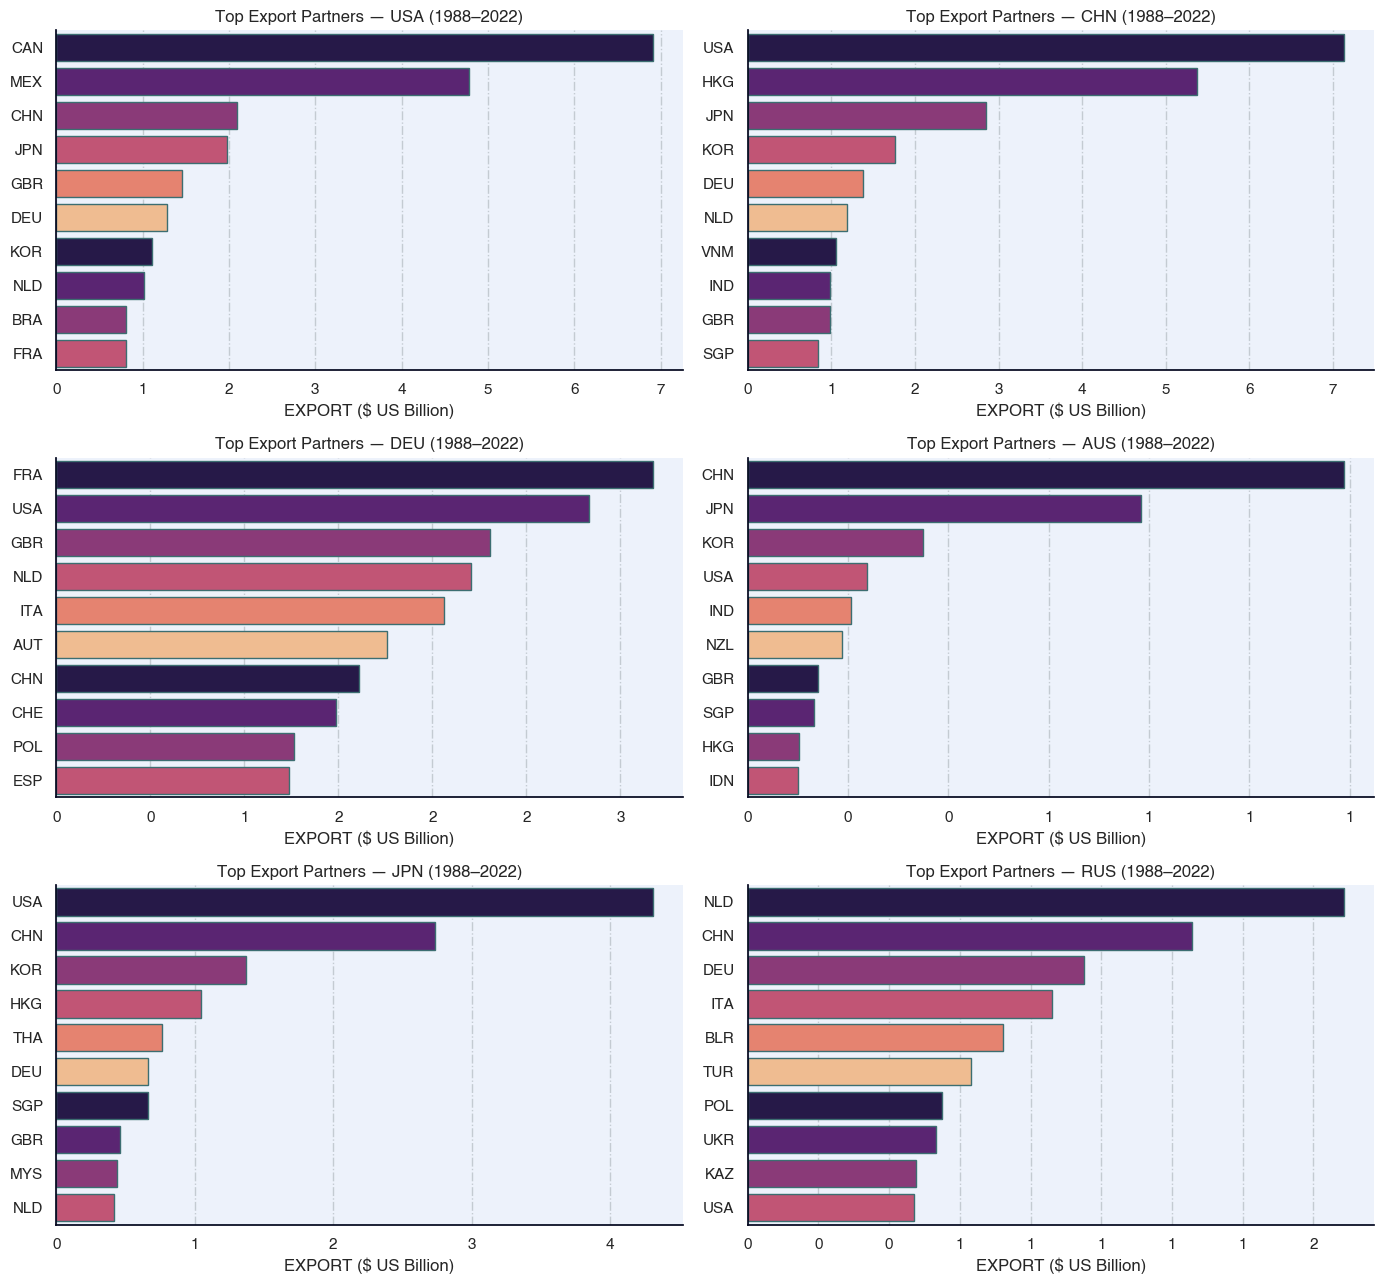

In [458]:
countries_top_partners = ["USA", "CHN", "DEU", "AUS", "JPN", "RUS"]
start_year, stop_year = 1988, 2022


def pick_scale(xmax):
  # Use billions if big enough, otherwise hundreds of millions
  if xmax >= 1e9:
    return 1e9, "$ US Billion"
  else:
    return 1e8, "$ US Billion"


n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 13))
axes = axes.flatten()

for i, country in enumerate(countries_top_partners):
  ax = axes[i]

  top = (
    df_trade.loc[
      (df_trade["ISO3_reporter"] == country) &
      (df_trade["Year"].between(start_year, stop_year))
      ]
    .groupby("ISO3_partner", as_index=False)["EXPORT"].sum()
    .nlargest(10, "EXPORT")  # <-- top 10
  )

  if top.empty:
    ax.text(0.5, 0.5, f"No data for {country}", ha="center", va="center")
    ax.axis("off")
    continue

  # Scale selection
  scale, scale_label = pick_scale(top["EXPORT"].max())
  top["EXPORT_scaled"] = top["EXPORT"] / scale

  # Largest on top
  order = top.sort_values("EXPORT_scaled", ascending=False)["ISO3_partner"].tolist()

  sns.barplot(
    data=top,
    y="ISO3_partner",
    x="EXPORT_scaled",
    hue="ISO3_partner",  # avoids seaborn warning when using a palette
    order=order,
    palette=colors,
    legend=False,
    ax=ax,
  )

  ax.set_title(f"Top Export Partners — {country} ({start_year}–{stop_year})", fontweight="bold")
  ax.set_ylabel("")
  ax.set_xlabel(f"EXPORT ({scale_label})")
  ax.grid(axis="x", alpha=0.25)

  # cleaner numeric ticks
  ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))

# Remove any unused axes
for j in range(len(countries_top_partners), n_rows * n_cols):
  fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(
  "graph_output/top_export_partners.png",
  dpi=500,
  bbox_inches="tight"
)
plt.show()

# Conditional Scatterplot

In [459]:
def conditional_scatter_export_vs_sanctions_nolags(
    df: pd.DataFrame,
    *,
    y_col: str = "EXPORT",  # your target column in this dataset
    # If you store sanctions as categories, we'll auto-sum them.
    # If you have a single total (e.g., 'sanction' or 'sanction_total'), we’ll use it.
    sanction_candidates: tuple = ("sanction_total", "sanction"),
    sanction_category_cols: tuple = ("arms", "military", "trade", "financial", "travel", "other"),
    # Controls we’ll try to use if present:
    control_candidates: tuple = ("GDP_reporter", "GDP_partner", "distw", "contig", "comlang_off", "colony", "smctry"),
    # Fixed effects:
    use_fixed_effects: bool = True,
    dyad_col: str | None = None,  # auto: uses 'dyad_id' if present, else builds from ISO3_* if both exist
    year_col: str = "Year",
    title: str = "Conditional scatter: EXPORT ⟂ X  vs  Sanctions ⟂ X (no lags)",
    lowess: bool = True,
    annotate_slope: bool = True,
):
  dff = df.copy()

  # --- Build/choose dyad_id for FE if needed ---
  if use_fixed_effects:
    if dyad_col is None:
      if "dyad_id" in dff.columns:
        dyad_col = "dyad_id"
      elif { "ISO3_reporter", "ISO3_partner" }.issubset(dff.columns):
        dff["dyad_id"] = dff["ISO3_reporter"].astype(str) + "_" + dff["ISO3_partner"].astype(str)
        dyad_col = "dyad_id"
      else:
        # Can't create dyad FE; we’ll drop FE silently
        use_fixed_effects = False

  # --- Choose sanctions column ---
  s_col = None
  # 1) total column if present
  for cand in sanction_candidates:
    if cand in dff.columns:
      s_col = cand
      break
  # 2) else sum categories if present
  if s_col is None:
    present_cats = [c for c in sanction_category_cols if c in dff.columns]
    if present_cats:
      dff["sanction_total"] = dff[present_cats].sum(axis=1).astype(float)
      s_col = "sanction_total"
  if s_col is None:
    raise ValueError("Could not find a sanctions column. Provide a total (e.g., 'sanction') or category columns.")

  # --- Controls: keep only those available ---
  controls = [c for c in control_candidates if c in dff.columns]

  # --- RHS for residualization ---
  rhs = " + ".join(controls) if controls else "1"
  if use_fixed_effects:
    # two-way FE (dyad & year) if possible
    rhs += f" + C({dyad_col}) + C({year_col})"

  # --- Keep complete cases only ---
  needed = [y_col, s_col] + controls
  if use_fixed_effects:
    needed += [dyad_col, year_col]
  dff = dff.dropna(subset=needed).copy()

  # --- Two-sided residualization (Frisch–Waugh–Lovell) ---
  mod_y = smf.ols(f"{y_col} ~ {rhs}", data=dff).fit()
  dff["rY"] = mod_y.resid

  mod_s = smf.ols(f"{s_col} ~ {rhs}", data=dff).fit()
  dff["rS"] = mod_s.resid

  # Partial slope of rY on rS
  fit = sm.OLS(dff["rY"], sm.add_constant(dff["rS"])).fit()

  # --- Plot ---
  plt.figure(figsize=(9, 6))
  ax = sns.regplot(
    data=dff, x="rS", y="rY",
    lowess=lowess, ci=None,
    scatter_kws=dict(alpha=0.25, s=16),
    line_kws=dict(color="crimson", lw=2),
  )
  ax.axhline(0, color="k", lw=1, alpha=0.5)
  ax.axvline(0, color="k", lw=1, alpha=0.5)

  fe_txt = "dyad & year FE" if use_fixed_effects else "no FE"
  ax.set_title(title + f"\n(controls: {', '.join(controls) if controls else '—'} | {fe_txt})")
  ax.set_xlabel("Sanctions residual  rS  (net of controls & FE)")
  ax.set_ylabel("EXPORT residual  rY  (net of controls & FE)")
  ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x:,.0f}"))
  ax.yaxis.set_major_formatter(FuncFormatter(lambda y, p: f"{y:,.0f}"))

  if annotate_slope:
    slope, pval, r2 = fit.params["rS"], fit.pvalues["rS"], fit.rsquared
    n = len(dff)
    txt = f"slope = {slope:.3f}   (p = {pval:.3g})   R² = {r2:.3f}   n = {n:,}"
    ax.text(0.02, 0.98, txt, transform=ax.transAxes,
            ha="left", va="top", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8"))

  plt.tight_layout()
  plt.show()

  return fit, dff[["rS", "rY"]]

# Case Research

For selected countries, select top 3 export partners and top 3 target states. Plot world map with the states and % of imports/exports from/to the partner country while under sanctions relationship.

## Prepare Data

In [460]:
# Define selected countries
SELECTED_COUNTRIES = ["USA"]
REPORTER_COUNTRY = "USA"
TRADE_TYPE = "IMPORT"
FILE_NAME = REPORTER_COUNTRY + "_" + TRADE_TYPE

# Extract top 3 export partners
top_partners = { }

for reporter in SELECTED_COUNTRIES:
  df_tmp = (
    df_merged
    .loc[df_merged["ISO3_reporter"] == reporter]
    .groupby("ISO3_partner", as_index=False)[TRADE_TYPE]
    .sum()
    .sort_values(TRADE_TYPE, ascending=False)
  )

  top_partners[reporter] = df_tmp

# Convert to DataFrame
top_partners = (
  pd.concat(top_partners, names=["ISO3_reporter"])
  .reset_index(level=0)
)
# Compute under sanction relationship
SANCTION_COLS = ["trade"]

df_rep = df_merged.loc[
  df_merged["ISO3_reporter"].isin(SELECTED_COUNTRIES)
].copy()

df_rep["under_sanction"] = (
  df_rep[SANCTION_COLS]
  .fillna(0)
  .gt(0)
  .any(axis=1)
  .astype(int)
)

case_study_df = df_rep.copy(deep=True)

In [461]:
# Aggregate total % of export from partner country during sanctions
agg_df = (
  case_study_df
  .assign(
    size_under_sanction=lambda x: x[TRADE_TYPE] * x["under_sanction"]
  )
  .groupby(
    ["ISO3_reporter", "ISO3_partner"],
    as_index=False
  )
  .agg(
    total_size=(TRADE_TYPE, "sum"),
    sanctioned_size=("size_under_sanction", "sum")
  )
)

agg_df["UNDER_SANCTION_PERCENT"] = (
    100 * agg_df["sanctioned_size"] / agg_df["total_size"]
)
agg_df[agg_df["UNDER_SANCTION_PERCENT"].isna()] = 0

## Draw Map

In [462]:
gdf = gpd.read_file("../data/countries/ne_110m_admin_0_countries.shp")
gdf = gdf.to_crs(epsg=4326)  # 177 countries

In [463]:
# Clean gdf
gdf = tu.clean_geopa(gdf, df_merged["ISO3_reporter"].unique(), drop_intersection=False)

In [464]:
gdf_map = gdf.merge(
  agg_df,
  left_on="ISO3",
  right_on="ISO3_partner",
  how="left"
)

# Countries not in agg_usa will be NaN -> treat as 0% (no measured sanctioned-share)
gdf_map["UNDER_SANCTION_PERCENT"] = gdf_map["UNDER_SANCTION_PERCENT"].fillna(0.0)

In [465]:
polygons = gv.Polygons(gdf_map, vdims=["UNDER_SANCTION_PERCENT"])

map_plot = polygons.opts(
  hv.opts.Polygons(
    color="UNDER_SANCTION_PERCENT",
    cmap="magma_r",
    clim=(0, 100),
    title="Test",
    # enable colorbar
    colorbar=False,

    line_color="#c36f09",
    line_width=1.5,

    projection=ccrs.LambertCylindrical(),
    width=1700,
    height=1000,
    xlim=(-170, 140),
    ylim=(-55, 85),
  )
)
hv.save(
  map_plot,
  f"graph_output/{FILE_NAME}-map",
  fmt="widgets",
)

from bokeh.io.webdriver import webdriver_control

webdriver_control.reset()

renderer = hv.renderer("bokeh")

renderer.instance(dpi=1000).save(map_plot, f"graph_output/{FILE_NAME}-map", fmt="png")

In [466]:
bar_df = gdf_map.copy()
bar_df = bar_df[bar_df["UNDER_SANCTION_PERCENT"] > 35]
bar_df = bar_df[bar_df["total_size"] > 1e6]
bar_df = (bar_df
          .sort_values("total_size", ascending=False)
          .head(50)
          .sort_values("UNDER_SANCTION_PERCENT", ascending=False)
          )

In [467]:
barplot_export_rc = {
  "axes.spines.right": False,
  "axes.spines.top": False,
  "axes.edgecolor": "#03071e",
  "grid.linestyle": "none",
  "grid.color": "#4a5759",
  "axes.facecolor": "white",
  "patch.edgecolor": "#9e2a2b",
}
sns.set_theme(style="whitegrid", rc=barplot_export_rc, font=BASE_FONT)

In [468]:
# import matplotlib.patheffects as pe
#
# bar_df_head = bar_df.head(10).copy(deep=True)
#
# norm = matplotlib.colors.Normalize(vmin=0, vmax=100)
# cmap = matplotlib.colormaps["OrRd"]
#
# bar_df_head["color"] = bar_df_head["UNDER_SANCTION_PERCENT"].apply(
#   lambda v: cmap(norm(v))
# )
#
# # --- Plot ---
# plt.figure(figsize=(5, 6))
#
# ax = sns.barplot(
#   data=bar_df_head,
#   y="ISO3_partner",
#   x="UNDER_SANCTION_PERCENT",
#   hue="ISO3_partner",
#   palette=list(bar_df_head["color"]),
#   dodge=False,
#   legend=False,
# )
#
# # --- Annotate exact values ---
# for p, pct, exp in zip(
#     ax.patches,
#     bar_df["UNDER_SANCTION_PERCENT"],
#     bar_df["total_size"] / 1e6
# ):
#   y = p.get_y() + p.get_height() / 2
#   x = pct + 1
#
#   # Bold percentage
#   ax.text(
#     x,
#     y,
#     f"{pct:.0f}%",
#     va="center_baseline",
#     ha="left",
#     fontsize=12,
#     weight="bold"
#   )
#
#   # Smaller, normal-weight export value
#   ax.text(
#     x - 2,  # horizontal offset so it appears after the %
#     y,
#     f"${exp:.0f} mil USD",
#     va="center_baseline",
#     ha="right",
#     fontsize=10,
#     fontweight="bold",
#     fontfamily="Helvetica",
#     path_effects=[pe.withStroke(linewidth=2.5, foreground="#edede9")],
#   )
#
# ax.set_xlabel("")
# ax.set_ylabel("")
# ax.set_xlim(0, 115)
# ax.set_xticks([])
# ax.spines["bottom"].set_visible(False)
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
#
# plt.tight_layout()
# plt.savefig(
#   f"graph_output/{FILE_NAME}-bar.png",
#   dpi=1000,
#   bbox_inches="tight"
# )
# plt.show()

In [469]:
def gradient_barh(ax, left, y, width, height, cmap, norm, zorder=2):
  grad = np.linspace(0, width, 256).reshape(1, -1)
  ax.imshow(
    grad,
    extent=[left, left + width, y - height / 2, y + height / 2],
    cmap=cmap,
    norm=norm,
    aspect="auto",
    interpolation="bicubic",
    zorder=zorder,
  )

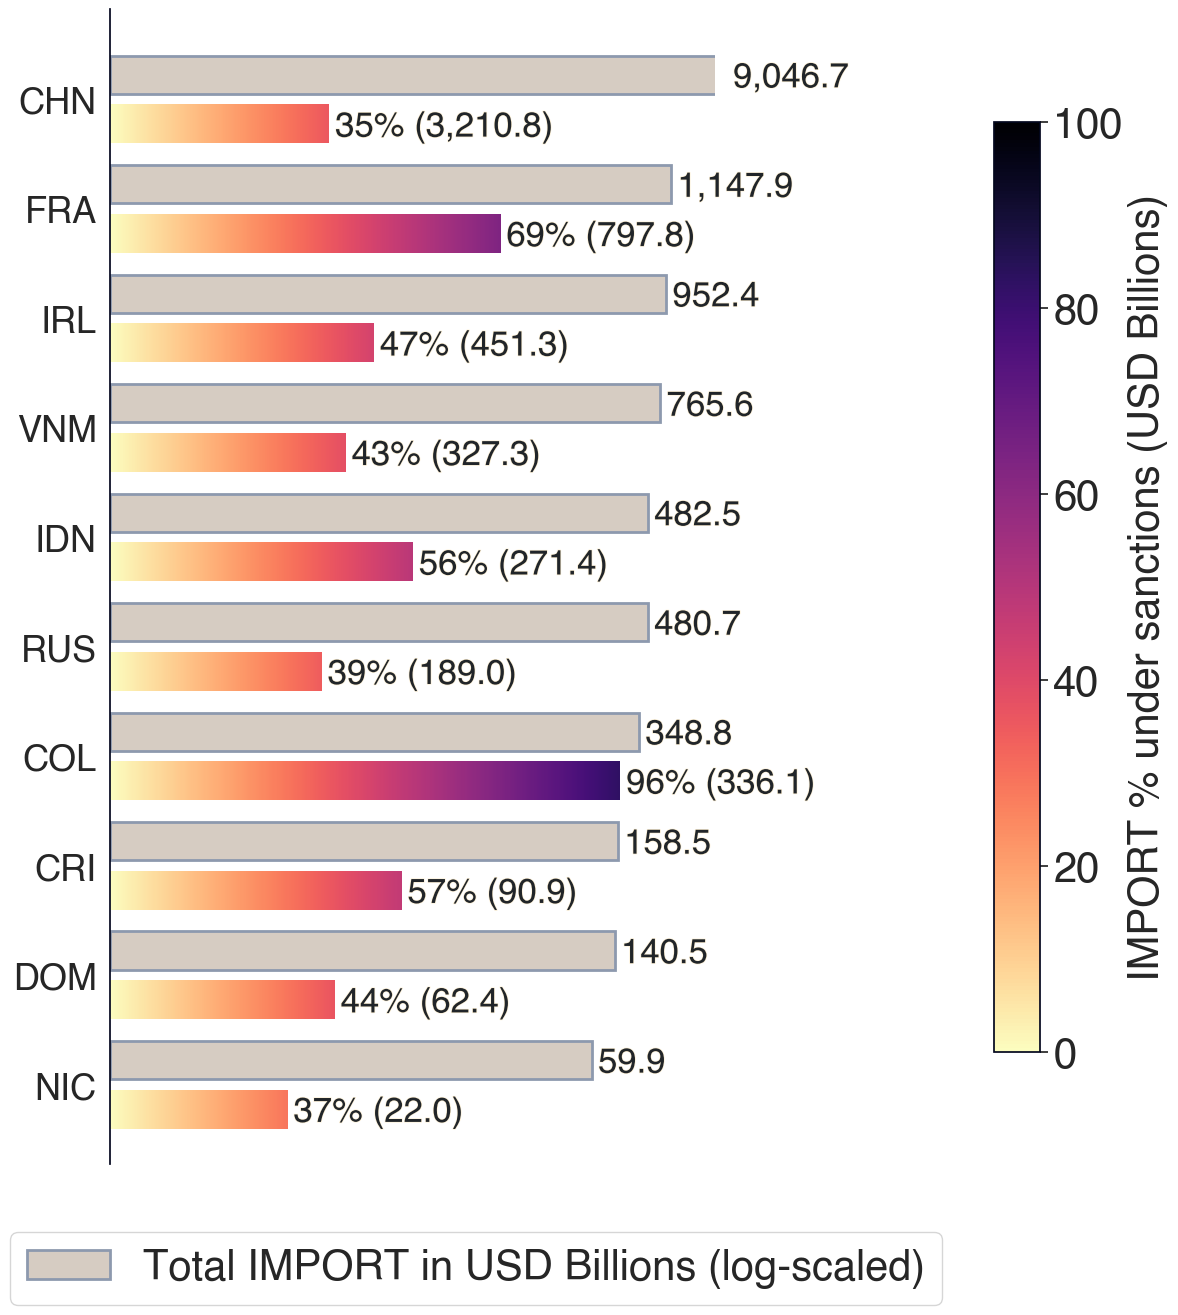

In [470]:
import matplotlib.cm as cm

# -----------------------------
# 1) Prepare data
# -----------------------------
double_bar_df = gdf_map.copy(deep=True)

double_bar_df = (
  double_bar_df
  .loc[double_bar_df["total_size"] > 1e6]
  .loc[double_bar_df["UNDER_SANCTION_PERCENT"] > 35]
  .sort_values("total_size", ascending=False)
  .head(10)
  .sort_values("UNDER_SANCTION_PERCENT", ascending=False)
  .head(15)
)

# Log-scale total trade BEFORE normalization (to tame China)
double_bar_df["TOTAL_LOG"] = np.log1p(double_bar_df["total_size"])

double_bar_df["TOTAL_SCALED"] = (
    double_bar_df["TOTAL_LOG"] / double_bar_df["TOTAL_LOG"].max() * 100
)

# Red bar = true percentage of the total bar
double_bar_df["SANCTION_SCALED"] = (
    double_bar_df["TOTAL_SCALED"]
    * double_bar_df["UNDER_SANCTION_PERCENT"] / 100
)

# Absolute total for labels
double_bar_df["TOTAL_MIL_USD"] = double_bar_df["total_size"] / 1e6

# Sort for plotting
double_bar_df = (
  double_bar_df
  .sort_values("TOTAL_SCALED", ascending=True)
  .reset_index(drop=True)
)

norm = matplotlib.colors.Normalize(vmin=0, vmax=100)
cmap = matplotlib.colormaps["magma_r"]

double_bar_df["PCT_COLOR"] = double_bar_df["UNDER_SANCTION_PERCENT"].apply(
  lambda v: cmap(norm(v))
)

# -----------------------------
# 2) Layout
# -----------------------------
countries = double_bar_df["ISO3_partner"].tolist()
y = np.arange(len(countries))
bar_h = 0.35  # thinner bars
gap = 0.1  # more space between bars
offset = bar_h / 2 + gap / 2

# Gray on top, red under
y_total = y + offset
y_pct = y - offset

# Colors
c_total = "#d6ccc2"
c_pct = "#b02a2e"
edge_c = "#8d99ae"

# -----------------------------
# 3) Plot
# -----------------------------
plt.figure(figsize=(12, 15))
ax = plt.gca()

# Total trade (scaled)
ax.barh(
  y_total,
  double_bar_df["TOTAL_SCALED"],
  height=bar_h,
  color=c_total,
  edgecolor=edge_c,
  linewidth=2,
  label=f"Total {TRADE_TYPE} in USD Billions (log-scaled)"
)

# Under sanctions (TRUE share of total)
for i in range(len(double_bar_df)):
  width = double_bar_df.loc[i, "SANCTION_SCALED"]

  gradient_barh(
    ax=ax,
    left=0,
    y=y_pct[i],
    width=width,
    height=bar_h,
    cmap=cmap,
    norm=norm,
    zorder=2
  )

# -----------------------------
# 4) Labels
# -----------------------------
for i in range(len(double_bar_df)):
  total_scaled = double_bar_df.loc[i, "TOTAL_SCALED"]
  sanc_scaled = double_bar_df.loc[i, "SANCTION_SCALED"]
  total_bil = double_bar_df.loc[i, "TOTAL_MIL_USD"]
  pct = double_bar_df.loc[i, "UNDER_SANCTION_PERCENT"]

  formatted_total = f"{total_bil:,.1f}"
  formatted_percent = f"{pct:.0f}% ({(total_bil * pct / 100):,.1f})"

  # Absolute total (gray bar)
  ax.text(
    total_scaled + 1,
    y_total[i],
    formatted_total,
    va="center_baseline",
    ha="left",
    fontsize=25,
    color="#212529",
    path_effects=[matplotlib.patheffects.withStroke(linewidth=1, foreground="#fdf0d5")]
  )

  # Percentage label (red bar)
  ax.text(
    sanc_scaled + 1,
    y_pct[i],
    formatted_percent,
    va="center_baseline",
    ha="left",
    fontsize=25,
    fontweight="bold",
    color="#212529",
    path_effects=[matplotlib.patheffects.withStroke(linewidth=1, foreground="#fdf0d5")]
  )

# -----------------------------
# 5) Axes & styling
# -----------------------------

# Add colorbar to the right
ax.set_yticks(y)
ax.set_yticklabels(countries, fontsize=26)

ax.set_xlim(0, 98)
ax.set_xticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_ylim(-0.5 - offset, len(y) - 0.4 + offset)

ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(x=0.02)

ax.legend(
  frameon=True,
  loc="lower left",
  bbox_to_anchor=(-0.2, -0.14),
  fontsize=30,
  title_fontsize=28
)

# plt.tight_layout()

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cax = plt.colorbar(sm, ax=ax, orientation="vertical", fraction=0.05, pad=0.3)

cax.set_label(f"{TRADE_TYPE} % under sanctions (USD Billions)", fontsize=30)
cax.ax.tick_params(labelsize=30)

# -----------------------------
# 6) Save
# -----------------------------
plt.savefig(
  f"graph_output/{FILE_NAME}-bar.png",
  dpi=500,
  bbox_inches="tight"
)
plt.show()

In [471]:
sns.set_theme(style="whitegrid", rc=custom_rc, font=BASE_FONT)